In [3]:
from tensorflow.keras import datasets

mnist = datasets.mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0

X_train = X_train.reshape((60000, 28, 28, 1))
X_test = X_test.reshape((10000, 28, 28, 1))

In [7]:
import tensorflow as tf
from tensorflow.keras import layers

class MyCNN(tf.keras.Model):
    def __init__(self):
        super().__init__()
        self.conv1 = layers.Conv2D(32, kernel_size=(5, 5), strides=(1, 1), 
                                   padding="same", activation="relu")
        self.pool1 = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))
        self.conv2 = layers.Conv2D(64, (2, 2), activation="relu", padding="same")
        self.pool2 = layers.MaxPool2D(pool_size=(2, 2), strides=(2, 2))
        self.dropout = layers.Dropout(0.25)
        self.flatten = layers.Flatten()
        self.dense1 = layers.Dense(1000, activation="relu")
        self.dense2 = layers.Dense(10, activation="softmax")

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.dropout(x, training=training)
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dense2(x)
        return x

In [15]:
inputs = tf.keras.Input(shape=(28, 28, 1))
model = MyCNN()
tf.keras.Model(inputs, model.call(inputs)).summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 28, 28, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 14, 14, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1000)           │     3,137,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,156,098 (12.04 MB)

 Trainable params: 3,156,098 (12.04 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
import time

model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

start_time = time.time()
hist = model.fit(X_train, y_train, epochs=5, verbose=1, validation_data=(X_test, y_test))

print("fit time: ", time.time() - start_time)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9636 - loss: 0.1152 - val_accuracy: 0.9844 - val_loss: 0.0475
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.9855 - loss: 0.0443 - val_accuracy: 0.9891 - val_loss: 0.0408
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9901 - loss: 0.0309 - val_accuracy: 0.9903 - val_loss: 0.0292
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9920 - loss: 0.0244 - val_accuracy: 0.9897 - val_loss: 0.0347
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9942 - loss: 0.0184 - val_accuracy: 0.9916 - val_loss: 0.0326
fit time:  118.5920193195343


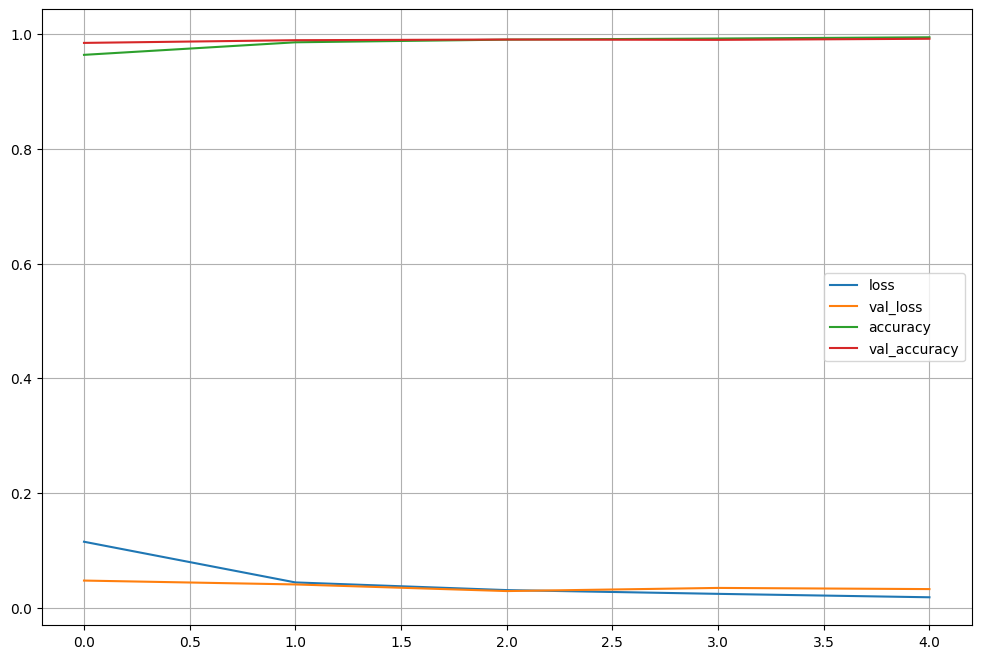

In [20]:
import matplotlib.pyplot as plt

plot_target = ["loss", "val_loss", "accuracy", "val_accuracy"]
plt.figure(figsize=(12, 8))

for each in plot_target:
    plt.plot(hist.history[each], label=each)

plt.legend()
plt.grid()
plt.show()

In [21]:
score = model.evaluate(X_test, y_test)
print("Test loss: ", score[0])
print("Testn accuracy: ", score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9916 - loss: 0.0326
Test loss:  0.0326429083943367
Testn accuracy:  0.991599977016449


In [23]:
import numpy as np

predicted_result = model.predict(X_test)
predicted_labels = np.argmax(predicted_result, axis=1)
predicted_labels[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

In [25]:
wrong_result = []

for n in range(0, len(y_test)):
    if predicted_labels[n] != y_test[n]:
        wrong_result.append(n)

len(wrong_result)

84

In [26]:
import random

samples = random.choices(population=wrong_result, k=16)
samples

[659,
 4078,
 445,
 4078,
 4507,
 9692,
 2921,
 3762,
 2953,
 3808,
 321,
 4740,
 3030,
 18,
 2118,
 2921]

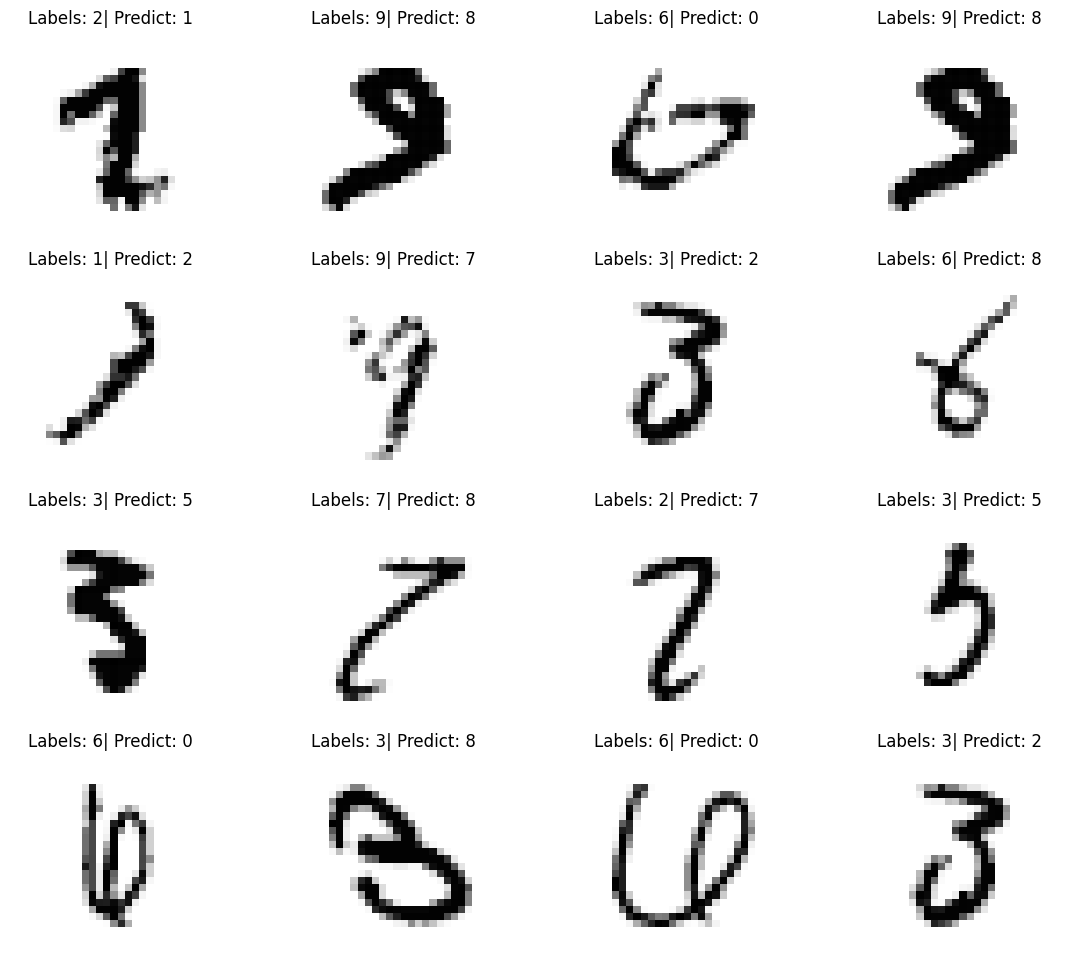

In [27]:
plt.figure(figsize=(14, 12))

for idx, n in enumerate(samples):
    plt.subplot(4, 4, idx + 1)
    plt.imshow(X_test[n].reshape(28, 28), cmap="Greys")
    plt.title("Labels: " + str(y_test[n]) + "| Predict: " + str(predicted_labels[n]))
    plt.axis("off")

plt.show()

In [28]:
model.save("MNIST _CNN_model.keras")